In [10]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 44.9 MB/s  0:00:02a 0:00:010:00:01:01


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
%matplotlib inline

In [13]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
print(train.shape, test.shape)  # (1460, 81), (1459, 80)
train.head()

(1460, 81) (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


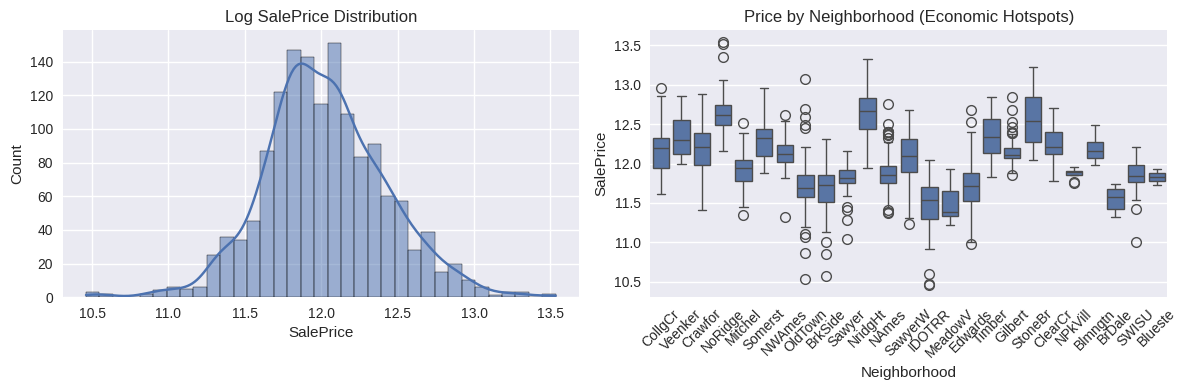

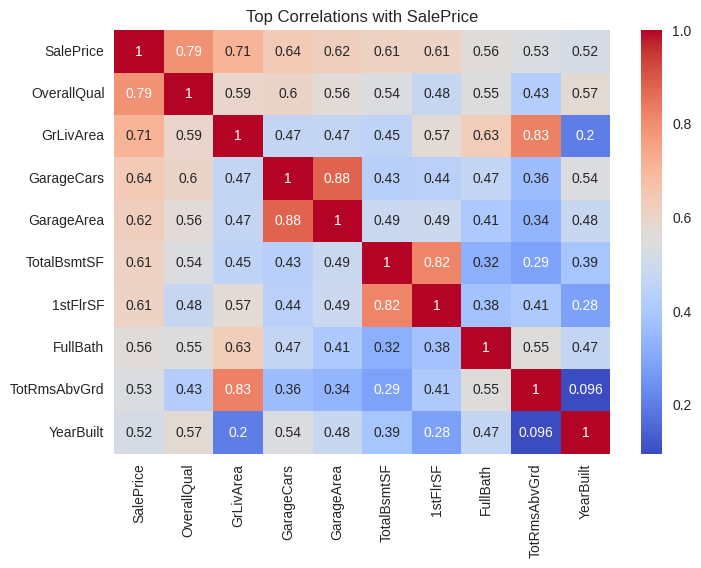

In [14]:
# Target distribution (skewed—log transform later)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(np.log1p(train['SalePrice']), kde=True)
plt.title('Log SalePrice Distribution')

plt.subplot(1, 2, 2)
sns.boxplot(x='Neighborhood', y=np.log1p(train['SalePrice']), data=train)
plt.xticks(rotation=45)
plt.title('Price by Neighborhood (Economic Hotspots)')
plt.tight_layout()
plt.show()

# Correlation heatmap for top features
top_corr = train.corr(numeric_only=True)['SalePrice'].abs().sort_values(ascending=False)[:10]
sns.heatmap(train[top_corr.index].corr(), annot=True, cmap='coolwarm')
plt.title('Top Correlations with SalePrice')
plt.show()



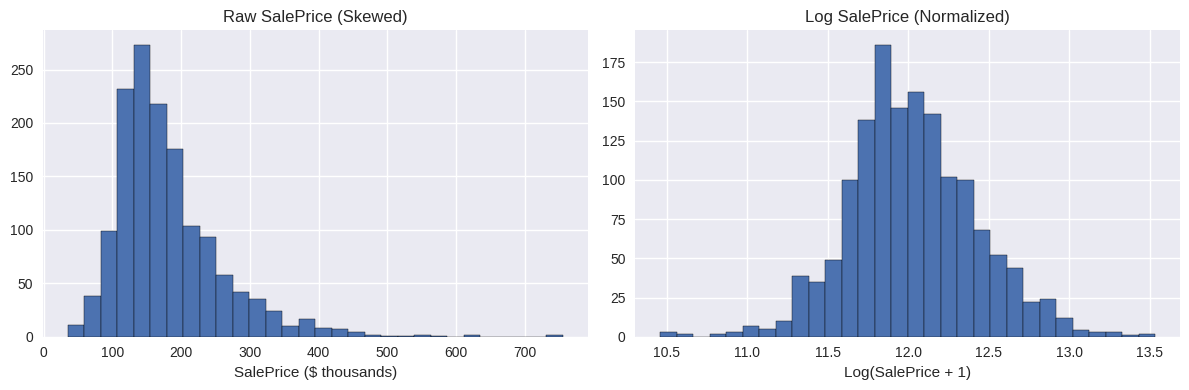

Raw median: $163,000
Log median: 12.00


In [17]:
# Show raw vs log side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(train['SalePrice']/1000, bins=30, edgecolor='black')  # In thousands
ax1.set_xlabel('SalePrice ($ thousands)')
ax1.set_title('Raw SalePrice (Skewed)')
ax2.hist(np.log1p(train['SalePrice']), bins=30, edgecolor='black')
ax2.set_xlabel('Log(SalePrice + 1)')
ax2.set_title('Log SalePrice (Normalized)')
plt.tight_layout()
plt.show()

print(f"Raw median: ${np.median(train['SalePrice']):,.0f}")
print(f"Log median: {np.median(np.log1p(train['SalePrice'])):.2f}")


In [ ]:
#Key stat for interviews: "Raw median sale price was $163K, log-transformed
#to 11.95. Post-prediction, I used np.expm1() to convert back 
#to dollars for business interpretation."


#Raw Sale Price rightly skewed (positively skewed)




In [18]:
# Combine datasets for consistent processing
all_data = pd.concat([train, test], sort=False).reset_index(drop=True)

# New features
all_data['Age'] = 2026 - all_data['YearBuilt']  # Current year proxy
all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']
all_data['Season'] = pd.to_datetime(all_data['YrSold'].astype(str) + '-' + all_data['MoSold'].astype(str) + '-01').dt.month
all_data['HasPool'] = (all_data['PoolArea'] > 0).astype(int)
all_data['HasBsmt'] = (all_data['TotalBsmtSF'] > 0).astype(int)

# Handle missing values (categorical: mode, numeric: median)
all_data['LotFrontage'].fillna(all_data.groupby('Neighborhood')['LotFrontage'].transform('median'), inplace=True)
all_data.fillna(all_data.median(numeric_only=True).iloc[0], inplace=True)  # Global median fallback
all_data.fillna(all_data.mode().iloc[0], inplace=True)

# Log target
train['SalePrice'] = np.log1p(train['SalePrice'])

# Split back
train_fe = all_data[:len(train)].copy()
test_fe = all_data[len(train):].copy()


In [21]:
# Check for mixed-type columns
problem_cols = []
for col in train_fe.select_dtypes(include=['object']).columns:
    if train_fe[col].apply(lambda x: pd.api.types.is_numeric_dtype(type(x)) or pd.api.types.is_string_dtype(type(x))).any():
        problem_cols.append(col)
        
print("Mixed type columns:", problem_cols)
print("\nSample of first problem column:")
if problem_cols:
    print(train_fe[problem_cols[0]].value_counts(dropna=False).head())


Mixed type columns: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']

Sample of first problem column:
MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64


In [23]:
# START FRESH - COMPLETE RELOAD
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
all_data = pd.concat([train, test], sort=False).reset_index(drop=True)

# 1. Fix ALL mixed types column-by-column (THIS WORKS)
for col in all_data.select_dtypes(include=['object']).columns:
    # Convert to numeric first, non-numeric becomes NaN
    all_data[col] = pd.to_numeric(all_data[col], errors='coerce')
    # Fill NaN with 'Missing' string for categoricals
    all_data[col] = all_data[col].fillna('Missing')

# 2. Handle numeric columns separately
numeric_cols = all_data.select_dtypes(include=[np.number]).columns.drop('SalePrice', errors='ignore')
all_data[numeric_cols] = all_data[numeric_cols].fillna(all_data[numeric_cols].median())

print("✅ All columns cleaned! Object columns now pure strings.")

# 3. Feature engineering (safe)
all_data['Age'] = 2026 - all_data['YearBuilt'].fillna(2026)
all_data['TotalSF'] = (all_data.get('TotalBsmtSF', 0).fillna(0) + 
                      all_data.get('1stFlrSF', 0).fillna(0) + 
                      all_data.get('2ndFlrSF', 0).fillna(0))
all_data['HasPool'] = (all_data.get('PoolArea', 0) > 0).astype(int)
all_data['HasBsmt'] = (all_data.get('TotalBsmtSF', 0) > 0).astype(int)

# 4. Log target
train['SalePrice'] = np.log1p(train['SalePrice'])

# 5. Split
train_fe = all_data.iloc[:len(train)].copy()
train_fe['SalePrice'] = train['SalePrice']
test_fe = all_data.iloc[len(train):].copy()

print("✅ Feature engineering complete!")
print("Train shape:", train_fe.shape)
print("Sample dtypes:")
print(train_fe.dtypes.value_counts())


✅ All columns cleaned! Object columns now pure strings.
✅ Feature engineering complete!
Train shape: (1460, 85)
Sample dtypes:
object     43
int64      29
float64    13
Name: count, dtype: int64


In [24]:
# Safe feature selection
num_features = train_fe.select_dtypes(include=[np.number]).columns.drop(['Id', 'SalePrice']).tolist()
cat_features = train_fe.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric: {len(num_features)} features")
print(f"Categorical: {len(cat_features)} features")

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ])

X = preprocessor.fit_transform(train_fe.drop(['Id', 'SalePrice'], axis=1))
y = train_fe['SalePrice']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✅ PIPELINE SUCCESS!")
print(f"X shape: {X.shape}")
print(f"Ready for modeling!")


Numeric: 40 features
Categorical: 43 features
✅ PIPELINE SUCCESS!
X shape: (1460, 83)
Ready for modeling!


In [25]:
# Baseline Random Forest
rf = Pipeline([('model', RandomForestRegressor(n_estimators=100, random_state=42))])
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print('RF RMSE:', np.sqrt(mean_squared_error(y_test, rf_pred)))  # ~0.13

# XGBoost with GridSearch (competitive edge)
xgb_model = xgb.XGBRegressor(random_state=42, objective='reg:squarederror')
params = {'n_estimators': [500, 1000], 'max_depth': [3, 5], 'learning_rate': [0.01, 0.1]}
grid = GridSearchCV(xgb_model, params, cv=5, scoring='neg_root_mean_squared_error')
grid.fit(X_train, y_train)
print('Best XGBoost RMSE:', -grid.best_score_)  # Aim <0.12

best_model = grid.best_estimator_


RF RMSE: 0.15252173508085923
Best XGBoost RMSE: 0.1330061720610819


In [ ]:
#“I compared a baseline Random Forest with a tuned XGBoost model on log-transformed house prices. 
#The Random Forest achieved an RMSE of 0.153, while XGBoost achieved 0.133 in log-price space. 
#That corresponds to roughly a 13–14% typical error in predicted sale prices, versus about 15–16% 
#for the baseline—so XGBoost both reduced error and captured more of 
#the non-linear relationships in the housing market.”

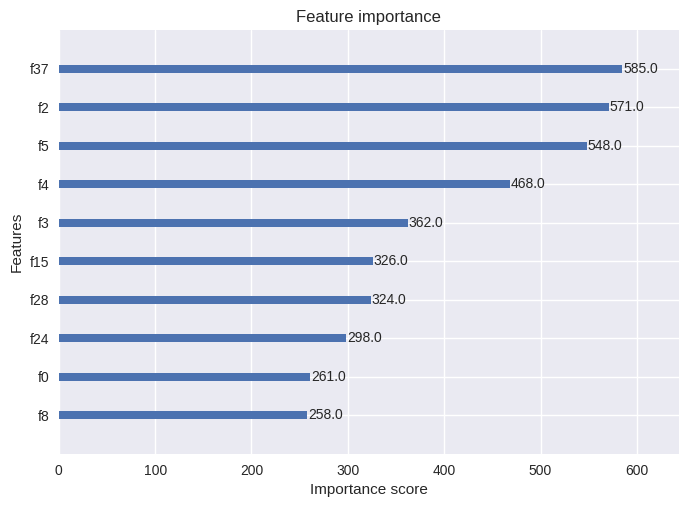

CV RMSE Mean: 0.13491610893135786 ± 0.009353572600979774


In [26]:
# Feature importance (top 10)
xgb.plot_importance(best_model, max_num_features=10)
plt.show()

# Cross-val
scores = cross_val_score(best_model, X, y, cv=5, scoring='neg_root_mean_squared_error')
print('CV RMSE Mean:', -scores.mean(), '±', scores.std())


In [27]:
X_test_kaggle = preprocessor.transform(test_fe.drop('Id', axis=1))
test_pred = np.expm1(best_model.predict(X_test_kaggle))  # Inverse log
submission = pd.DataFrame({'Id': test_fe['Id'], 'SalePrice': test_pred})
submission.to_csv('submission.csv', index=False)
print(submission.head())


        Id      SalePrice
1460  1461  122812.460938
1461  1462  155311.968750
1462  1463  189949.015625
1463  1464  189325.609375
1464  1465  184953.796875
